In [1]:
import time
import datetime
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES,SAMPLERATE,INPUT_SHAPE,Q_FACTOR,FRAME_LAG,plot_histogram,count_midi_notes
import soundfile as sf
from fretboardnonredundant import FretBoard
from pathlib import Path
from write_tfrecord_parallel import write_tfrecord_parallel
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

#training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
training_dir='/data2/data_slices'
#subset = '/data/training_subset'
subset='/data2/training_subset_acoustic'
input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)


numfiles=len(input_filepaths)#500#18000#3426

numfiles=min(numfiles,len(input_filepaths))
print("Loading a fixed set of ",numfiles," files")# Amount to ~1GB on disk without filtering or 312GB with prefiltering
input_filepaths=input_filepaths[:numfiles]
feature_description = {
        "audio_path": tf.io.FixedLenFeature([], tf.string),
        "frame_nr":   tf.io.FixedLenFeature([], tf.int64),
        "output":     tf.io.FixedLenFeature([], tf.string),
    }


print(f'Number of input files: {len(input_filepaths)}')

# tf.py_function that creates a histogram of MIDI note occurrences from the label data in the TFRecord files
def createhist(labels):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    output_data = labels.numpy()  # Reshape to (num_frames, 89)
    for note in range(OUTPUT_DIM_NOTES):
        if output_data[note] == 1:
            hist[note] += 1
    return hist

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = parsed["audio_path"]
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    # hist = tf.py_function(createhist, [label], tf.int32)
    return audio,label

def create_dataset_old(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE,use_unbounded_threadpool=True,deterministic=False)
    dataset=dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def count_midi_notes_old(dataset):
    # hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    # 2. Define the reduction function
    # 'old_state' is the current sum, 'next_element' is (features, labels)
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # Cast labels to int32 to match state and prevent overflow
        return old_state + tf.cast(labels, tf.int32)

    # 3. Perform the reduction
    # This happens in the TF graph and is memory-efficient
    hist = dataset.reduce(initial_state, reduce_fn)
    
    return hist.numpy()
    # Parse the entire batch at once (Vectorized Parsing)
def parse_batch(serialized_batch):
        # Note: feature_description stays the same, but we use parse_example
    parsed = tf.io.parse_example(serialized_batch, feature_description)
        # No need for decode_raw if your data is stored as float/int in the proto, 
        # but if it is bytes, decode_raw works on the whole batch dimension too.
    # audio = tf.io.decode_raw(parsed["audio_path"], tf.string)
    #decode the audio path as string
    audio_path = parsed["audio_path"]
    #print type and value of audio_path
    # print("Audio path type:", audio_path.dtype)
    # print("Audio path value:", audio_path)
    frame_nr = parsed["frame_nr"]

    label = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio_path,frame_nr, label


def create_dataset(filepaths, batch_size=256):
    # Convert file list to a dataset of strings
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    
    # Read from multiple files in parallel
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # Batch the RAW serialized protos FIRST
    dataset = dataset.batch(batch_size)
    

    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.prefetch(tf.data.AUTOTUNE)



def create_balanced_dataset(filepaths, note_count_max, batch_size=256):
    # 1. Start with the RAW strings (Parallel I/O)
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # 2. Vectorized Parsing (The "Turbo" Step)
    # We batch the raw strings, parse them as a block, then unbatch to filter
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch().prefetch(tf.data.AUTOTUNE)  # Back to individual (audio, label) pairs
    
    # 3. Stateful Filter Logic
    initial_hist = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    def scan_fn(running_hist, element):
        audio,frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)
        
        # Identify counts of notes present in this sample (where label == 1)
        # If labels is [0, 1, 1] and hist is [500, 10, 1000], active_counts is [10, 1000]
        active_counts = tf.boolean_mask(running_hist, labels_int > 0)
        
        # "Only keep if the active note with the LEAST count is under the limit"
        # We use tf.reduce_min to find that smallest bin value.
        # If the sample is empty (no notes), we'll default to False to avoid noise.
        has_notes = tf.reduce_any(labels_int > 0)
        min_active_count = tf.reduce_min(active_counts) if has_notes else note_count_max
        
        can_keep = has_notes & (min_active_count < note_count_max)
        
        # Update histogram: only add labels if we decided to keep the sample
        new_hist = tf.where(can_keep, running_hist + labels_int, running_hist)
        
        return new_hist, (audio,frame_nr, labels, can_keep)

    # Apply scan and filter out the 'False' results
    dataset = dataset.scan(initial_state=initial_hist, scan_func=scan_fn)
    dataset = dataset.filter(lambda a,fnr, l, keep: keep)
    dataset = dataset.shuffle(buffer_size=20000, reshuffle_each_iteration=True)
    
    # 4. Final Polish
    # Remove the 'keep' boolean, re-batch for training, and prefetch
    dataset = dataset.map(lambda a,fnr, l, k: (a,fnr, l), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Fast label-only parser (no prints, no audio_path parsing overhead)
label_only_desc = {
    "audio_path": tf.io.FixedLenFeature([], tf.string),
    "frame_nr":   tf.io.FixedLenFeature([], tf.int64),
    "output":     tf.io.FixedLenFeature([], tf.string),
}

def parse_batch_fast(serialized_batch):
    parsed = tf.io.parse_example(serialized_batch, label_only_desc)
    audio_path = parsed["audio_path"]
    frame_nr   = parsed["frame_nr"]
    label      = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio_path, frame_nr, label

def create_balanced_dataset_poly(filepaths, note_max, poly_max,max_active_notes=6, batch_size=256):
    # 1. Parallel I/O
    dataset = tf.data.TFRecordDataset(
        filepaths,
        num_parallel_reads=tf.data.AUTOTUNE,
        buffer_size=256 * 1024 * 1024  # 256MB read buffer
    )

    # 2. Batch → parse → unbatch (vectorized parsing, no print statements)
    dataset = (
        dataset
        .batch(batch_size)
        .map(parse_batch_fast, num_parallel_calls=tf.data.AUTOTUNE)
        .unbatch()
        .prefetch(tf.data.AUTOTUNE)  # ← prefetch BEFORE scan to feed it fast
    )

    # 3. Stateful scan (unavoidably sequential, but keep it lean)
    initial_state = (
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32),  # note histogram
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32),  # poly histogram
    )

    def prefilter(audio,frame_nr,labels):
        labels_int = tf.cast(labels, tf.int32)

        num_active_silent = tf.reduce_sum(labels_int)
        return (num_active_silent > 0) & (num_active_silent<=(max_active_notes+1)) # only allow up to max_active_notes and the silence note
    dataset=dataset.filter(prefilter)

    def combined_scan_fn(state, element):
        note_hist, poly_hist = state
        audio, frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)

        num_active = tf.reduce_sum(labels_int[:(OUTPUT_DIM_NOTES-1)])
        poly_idx   = tf.minimum(num_active, OUTPUT_DIM_NOTES - 1)

        # Polyphony check
        keep_poly = tf.gather(poly_hist, poly_idx) < poly_max

        # Note frequency check — avoid boolean_mask (dynamic shape, slow)
        # Instead: mask counts, find min among active notes only
        active_mask   = labels_int > 0
        masked_counts = tf.where(active_mask, note_hist, tf.fill([OUTPUT_DIM_NOTES], note_max))
        min_note_count = tf.reduce_min(masked_counts)
        keep_note = min_note_count < note_max

        can_keep = keep_poly & keep_note# & (num_active > 0) & (num_active<=(max_active_notes+1))

        # Update note histogram
        new_note_hist = tf.cond(
            can_keep,
            lambda: note_hist + labels_int,
            lambda: note_hist
        )

        # Update poly histogram
        poly_update   = tf.one_hot(poly_idx, depth=OUTPUT_DIM_NOTES, dtype=tf.int32)
        new_poly_hist = tf.cond(
            can_keep,
            lambda: poly_hist + poly_update,
            lambda: poly_hist
        )

        return (new_note_hist, new_poly_hist), (audio, frame_nr, labels, can_keep)

    dataset = dataset.scan(initial_state=initial_state, scan_func=combined_scan_fn)

    # 4. Filter, THEN shuffle (smaller buffer since already filtered)
    dataset = (
        dataset
        .filter(lambda a, fnr, l, keep: keep)
        .map(lambda a, fnr, l, k: (a, fnr, l))
        .shuffle(buffer_size=5000, reshuffle_each_iteration=True)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return dataset

def filter_notes(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels

        for note in range(OUTPUT_DIM_NOTES):
            hist[note]+=labels[note]
            # if labels[note] == 1:
            #     if hist[note] >= note_count_maximum: 
            #         result=False
        # assert labels[OUTPUT_DIM_NOTES-1]==0
        
        # Check the minimum count for notes that are present in the current sample
        masks = labels == 1
        #print("Mask for current sample:", masks)
        min_count = np.min(hist[masks]) if np.any(masks) else 0
        # print("Current histogram:", hist)
        # print("Min count for current sample:", min_count)
        # if min_count>0:
        #     print("Minimum count for notes with occurrences:", min_count)
        if min_count >= note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

def filter_polyphony(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels
        num_active_notes=np.sum(labels[:(OUTPUT_DIM_NOTES-1)])
        if num_active_notes>=hist.shape[0]:  
            print("Warning: num_active_notes exceeds histogram size. This should not happen. num_active_notes:", num_active_notes, "histogram size:", hist.shape[0])
            return False        

        if hist[num_active_notes] > note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        else:
            hist[num_active_notes]+=1
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function






I0000 00:00:1775578738.034092  109921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775578738.071514  109921 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775578739.399620  109921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading a fixed set of  8894  files
Number of input files: 8894


Script started at: 2026-04-07 18:19:00.535536
Dataset created, counting MIDI notes...
This may take a while...


W0000 00:00:1775578740.630070  109921 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1775578740.637486  109921 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775578740.767930  109921 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 639 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1775578741.140755  110075 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 268435456


Histogram of concurrent notes in the polyphony-filtered dataset: [7500000 7500000 7500000 7500000 7500000 7500000 7500000   65620       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0       0       0
       0       0       0       0       0       0       0   

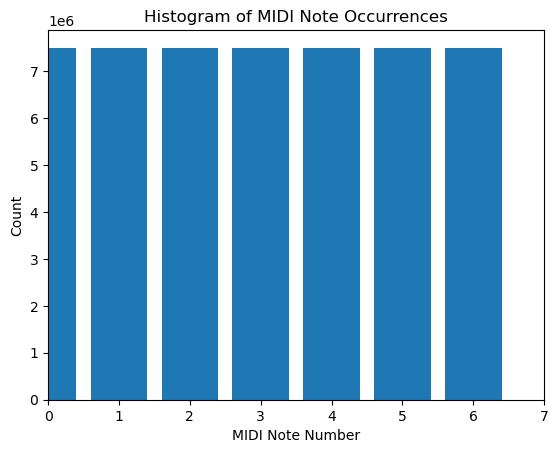

Histogram of MIDI notes in the polyphony-filtered dataset: [       0        0        0        0        0        0        0        0
        0        0        0        0        0        0        0        0
        0        0        0        0        0        0        0        0
       42        0        0        0        0        0        0        0
        0        0        0    16320    15223   104573   242092   419979
  4256509  1573413  1294100  4046346  1233574  6559039  1276595  6990182
  5025504  1920838  8976115  2019278 10672626  3177960  3808499 11326145
  3488429 11564815  2493007  9727986  8815381  4527555  9389622  2574441
 11449674  3420487  4765723  5019217  1198332  1888030   392611  1008392
   336482   219433   313878    54820   192428    44992    25283    34904
    18391    22244     1903     6789     1285       50     1768      501
     5241      164        0      130        0        0        0        0
        0        0        0        0        0        0        0  

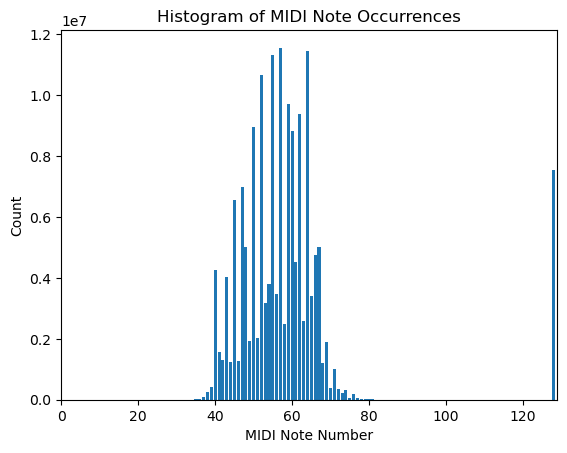

Writing polyphony-filtered dataset to TFRecord: /data2/training_subset_acoustic/filtered_poly_data
Write parallel using 29 workers
5000 protos queued ...
10000 protos queued ...
15000 protos queued ...
20000 protos queued ...
25000 protos queued ...
30000 protos queued ...
35000 protos queued ...
40000 protos queued ...
45000 protos queued ...
50000 protos queued ...
55000 protos queued ...
60000 protos queued ...
65000 protos queued ...
70000 protos queued ...
75000 protos queued ...
80000 protos queued ...
85000 protos queued ...
90000 protos queued ...
95000 protos queued ...
100000 protos queued ...
105000 protos queued ...
110000 protos queued ...
115000 protos queued ...
120000 protos queued ...
125000 protos queued ...
130000 protos queued ...
135000 protos queued ...
140000 protos queued ...
145000 protos queued ...
150000 protos queued ...
155000 protos queued ...
160000 protos queued ...
165000 protos queued ...
170000 protos queued ...
175000 protos queued ...
180000 protos 

In [ ]:
write_block = True
plot_block = True
#print the time when the script started
from common import count_concurrent_notes_distribution,filter_polyphony
print("Script started at:", datetime.datetime.now())

# Load the filtered dataset and create a histogram over the number of concurrent notes in the labels

Path(subset).mkdir(parents=True,exist_ok=True)
if plot_block:
    dataset = create_dataset(input_filepaths)
    print("Dataset created, counting MIDI notes...")
    print("This may take a while...")

    # midi_histogram = count_midi_notes(dataset)
    # plot_histogram(midi_histogram)
note_count_maximum = 2e7
poly_count_maximum = 0.75e7
# Now run it
if plot_block:
    # concurrent_notes_histogram = count_concurrent_notes_distribution(dataset)
    # print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
    # plot_histogram(concurrent_notes_histogram[:7],7)
    
    filtered_poly_ds=create_balanced_dataset_poly(input_filepaths, note_max=int(note_count_maximum), poly_max=int(poly_count_maximum), batch_size=256)
    
    #filtered_poly_ds=filter_polyphony(filtered_poly_ds.unbatch(),6,False)

    polyphony_histogram = count_concurrent_notes_distribution(filtered_poly_ds,has_filtered_audio=False)
    print("Histogram of concurrent notes in the polyphony-filtered dataset:", polyphony_histogram)
    plot_histogram(polyphony_histogram[:7],7)

filtered_poly_ds=create_balanced_dataset_poly(input_filepaths, note_max=int(note_count_maximum), poly_max=int(poly_count_maximum), batch_size=256)
#filtered_poly_ds=filter_polyphony(filtered_poly_ds,6,False)
# if plot_block:
notes_histo=count_midi_notes(filtered_poly_ds)
print("Histogram of MIDI notes in the polyphony-filtered dataset:", notes_histo)
plot_histogram(notes_histo)

# write the values of notes_histo to a csv file in order to create weights for the labels in the loss function during training
import csv




if write_block:
    with open(os.path.join(subset, 'note_histogram.csv'), mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['MIDI Note', 'Count'])
        for note, count in enumerate(notes_histo):
            writer.writerow([note, count])
    # write the filtered dataset to a new TFRecord file
    output_filepath_poly = f"{subset}/filtered_poly_data"
    print("Writing polyphony-filtered dataset to TFRecord:", output_filepath_poly)
    write_tfrecord_parallel(filtered_poly_ds, output_filepath_poly,num_workers=29)
    print(f"Polyphony-filtered dataset written to {output_filepath_poly}")

#print the time when the script finished
print("Script finished at:", datetime.datetime.now())
# poweroff the machine after processing


# os.system("poweroff")


In [ ]:

# #poweroff the machine after processing
# # show a modal window with the message "Processing finished. Do you want to power off the machine?" and two buttons "Yes" and "No". If the user clicks "Yes", poweroff the machine. If the user clicks "No", do nothing.
# # the window should have a countdown timer of 30 seconds, after which it will automatically poweroff the machine if the user has not made a choice. The window should also display the time when the processing finished and the total processing time.
# import tkinter as tk
# from tkinter import messagebox
# import threading
# import time
# def countdown(count):
#     while count > 0:
#         time.sleep(1)
#         count -= 1
#     # If the user has not made a choice after the countdown, poweroff the machine
#     os.system("poweroff")
# def on_closing():
#     if messagebox.askokcancel("Quit", "Processing finished. Do you want to power off the machine?"):
#         os.system("poweroff")
# root = tk.Tk()
# root.protocol("WM_DELETE_WINDOW", on_closing)
# root.title("Processing Finished")
# label = tk.Label(root, text="Processing finished at: {}\nTotal processing time: {:.2f} seconds\nThe machine will automatically power off in 30 seconds.".format(datetime.datetime.now(), (datetime.datetime.now() - datetime.datetime.strptime("2024-06-01 00:00:00", "%Y-%m-%d %H:%M:%S")).total_seconds()))   
# label.pack(padx=20, pady=20)
# # Start the countdown in a separate thread so it doesn't block the GUI
# threading.Thread(target=countdown, args=(30,)).start()
# root.mainloop()


In [ ]:
import os
os.system("sleep 10")
os.system("poweroff")

In [ ]:
# import os
# os.system("sleep 10")
# os.system("poweroff")

: 